<a href="https://colab.research.google.com/github/zaarakhan-dev/advanced-machine-learning-experiments/blob/main/exp_3_decision_tree_ID3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exp 3: Implementing Decision Tree Classifier using ID3(using Entropy).


## Step 1: Import Required Libraries
Import essential libraries: **pandas** for data handling, **sklearn** modules for the **ID3 decision tree classifier** and **label encoding**, and **matplotlib.pyplot** for tree visualization.

In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

## Step 2: Create and Load the Dataset
Construct the standard **Play Tennis** dataset as a dictionary and convert it into a Pandas DataFrame.

In [4]:
# Create the Play Tennis dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],

    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
                    'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],

    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],

    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Weak', 'Strong', 'Strong', 'Strong', 'Weak', 'Strong'],

    # Target column that tells whether tennis should be played or not
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
             'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
df

,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Strong,Yes


## Step 3: Categorical Feature Encoding
Convert categorical string values across all columns into numerical labels using **LabelEncoder** so they can be processed by Scikit-Learn.

In [5]:
# encode the data
encoder = LabelEncoder()

for col in df.columns:
  df[col]= encoder.fit_transform(df[col])


## Step 4: Inspect Encoded Data
Display the DataFrame to verify that all features and target classes have been converted to numeric values.

In [6]:
df

,Outlook,Temperature,Humidity,Wind,Play
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,0,1


## Step 5: Separate Features and Target Variable:
 Split the dataset into input feature matrix $X$ (dropping the target column **'Play'**) and target vector $y$ (**'Play'**).




In [7]:
# seperate the input features in input and target
X = df.drop('Play',axis=1)  # input variable
y = df['Play']              # target variable
X

,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1
5,1,0,1,0
6,0,0,1,0
7,2,2,0,1
8,2,0,1,1
9,1,2,1,0


In [8]:
y

,Play
0,0
1,0
2,1
3,1
4,1
5,0
6,1
7,0
8,1
9,1


## Step 6: Initialize the Decision Tree Model
Initialize the **DecisionTreeClassifier** using **criterion='entropy'** to mimic the ID3 algorithm, which relies on Information Gain and Entropy for splitting.

In [9]:
# create a decision tree model using criterion= 'entropy' bcz ID3 uses entropy
model = DecisionTreeClassifier(criterion='entropy', random_state=0)
model


DecisionTreeClassifier(criterion='entropy', random_state=0)

## Step 8: Train the Model:
Fit the Decision Tree classifier onto the feature set $X$ and target labels $y$.

In [10]:
# Train the decision tree model
model.fit(X,y)
print("Decision Tree model created successsfully.")

Decision Tree model created successsfully.


## Step 9: Make Predictions:
Select a test row from the dataset to perform an inference using **model.predict()** and compare the predicted output against the actual label.

In [11]:
# Predict
# take the first row / column of the dataset
new_data = X.iloc[[2]]  # index location - select first which row to predict from
prediction = model.predict(new_data)
# display result
print("Actual Data:" , y.iloc[2])
print("Predicted result: ", prediction[0])

Actual Data: 1
Predicted result:  1


## Step 10: Visualize the Decision Tree
Plot the generated decision tree using **plot_tree** from **sklearn.tree** with feature names and class labels for clear interpretability.

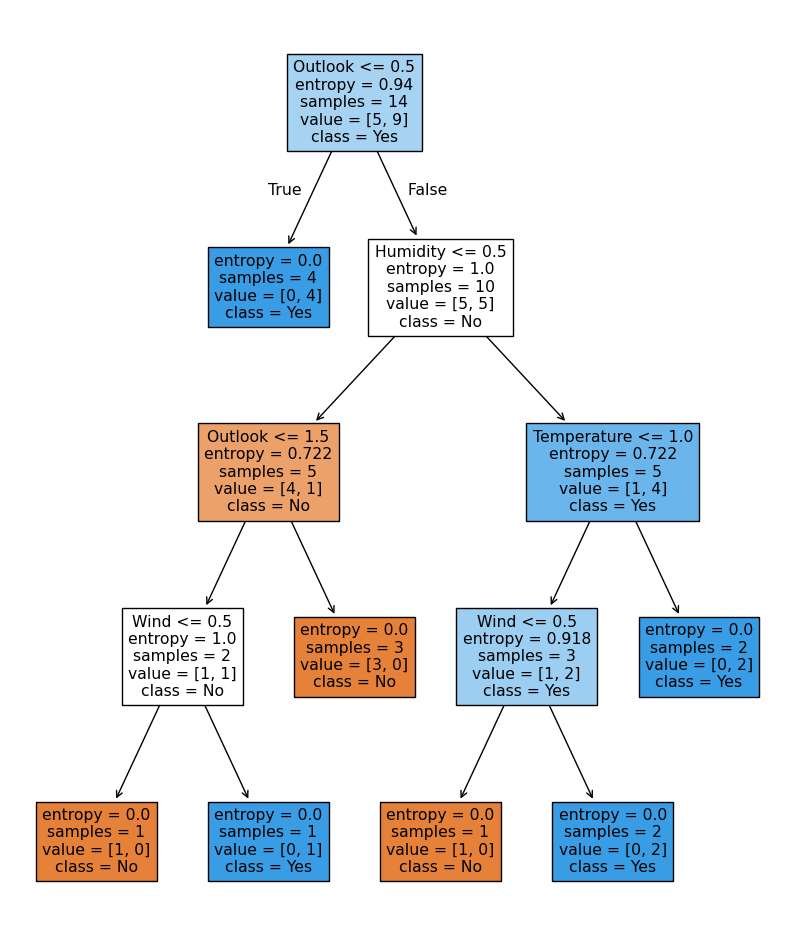

In [13]:
plt.figure(figsize=(10,12))
plot_tree(model, feature_names = X.columns, class_names=['No','Yes'], filled=True)
plt.show()